In [1213]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as const
from scipy import optimize
from sklearn.linear_model import LinearRegression
from set_rcParams import set_rcParams
set_rcParams()
import glob


print(sorted(glob.glob("*.csv"))[2:])

['testing_csv_distribution_0005.csv', 'testing_csv_distribution_0010.csv', 'testing_csv_distribution_0015.csv', 'testing_csv_distribution_0020.csv', 'testing_csv_distribution_0025.csv', 'testing_csv_distribution_0030.csv', 'testing_csv_distribution_0035.csv', 'testing_csv_distribution_0040.csv', 'testing_csv_distribution_0045.csv', 'testing_csv_distribution_0050.csv', 'testing_csv_distribution_0055.csv', 'testing_csv_distribution_0060.csv', 'testing_csv_distribution_0065.csv', 'testing_csv_distribution_0070.csv', 'testing_csv_distribution_0075.csv', 'testing_csv_distribution_0080.csv', 'testing_csv_distribution_0085.csv', 'testing_csv_distribution_0090.csv', 'testing_csv_distribution_0095.csv']


In [1214]:
# the final temperature from a uniformly distributed speed
m = 1 * u.kg
v_max = 0.5 * u.m / u.s
T_f = (m * v_max**2 / (9 * const.k_B)).to(u.K)


def f_M(v, T, m):
  return 4 * np.pi * v**2 * (m / (2 * np.pi * const.k_B.value * T))**(3/2) * np.exp(- m * v**2 / (2 * const.k_B.value * T))


def f_M_v(v, T, m):
  return (m / (2 * np.pi * const.k_B.value * T))**(1/2) * np.exp(- m * v**2 / (2 * const.k_B.value * T))


def uniform_dist(v, v_max):
  # zeros = np.zeros_like(v)[np.where(v < v_max)[0]]
  initial = np.ones_like(v)
  initial[np.where(v > v_max)[0]] = 0
  return 1 / v_max * initial

Formulation of the calculation of the relaxation rate is given by 
Investigation of the ellipsoidal-statistical Bhatnagar-Gross-Krook kinetic model applied to the gas-phase transport of heat and tangential momentum between parallel walls
https://doi.org/10.1063/1.3558869

In [1215]:
omega = 1
alpha = 2.13986
mu_inf_mu_1 = 1
mu_ref = 21.27e-6
m = 6.6e-26
k_b = const.k_B.value

T_x = 373
T_yz = 273
T_f = (2 * 273 + 373) / 3
T_ref = T_f


Pr = 1
ratio = alpha * (5 - 2 * omega) * (7 - 2 * omega) * Pr / (5 * (alpha + 1) * (alpha + 2) * (mu_inf_mu_1))
print(ratio)

speed_range = np.linspace(0, 1, 1000) * u.m/ u.s
n = 1
sigma = 1
nu_c = n
nu = nu_c * ratio

m = 6.6e-26
v_range = np.linspace(-1e3, 1e3, 1000)

0.4938677605727688


In [1216]:
# i = 1
# bins = 30
# # bgk_x = lambda v, nu, t: f_M_v(v, T_f, m) + np.exp(-nu * t) * (f_M_v(v_range, T_x, m) - f_M_v(v, T_f, m))
# # bgk_yz = lambda v, nu, t: f_M_v(v, T_f, m) + np.exp(-nu * t) * (f_M_v(v_range, T_yz, m) - f_M_v(v, T_f, m))

# data = pd.read_csv("testing_csv_distribution_0010.csv")
# v_x_centers = ((data["v_x_lower"] + data["v_x_upper"]) / 2).to_numpy()
# v_x_counts = data["v_x"]
# total = np.trapezoid(v_x_counts, v_x_centers)

# plt.figure()
# plt.plot(v_x_centers, v_x_counts / total)
# plt.plot(v_x_centers, f_M_v(v_x_centers, T_x, m))
# plt.show()


In [1217]:


def getGrowthRate(path : str, start_time_step=10, end_time_step=110, step_size=10, dt=5e-2, fitting_start_index=0,fitting_stop_index=5):
  errors = [[], [], []]
  fits = []
  rates = np.zeros(3)
  components = ["x", "y", "z"]
  time = (np.arange(start_time_step, end_time_step, step_size) * dt)
  start_idx = fitting_start_index
  stop_idx = fitting_stop_index
  fitting_time = time[start_idx:stop_idx].reshape((-1, 1))

  for i in range(start_time_step, end_time_step, step_size):

    data = pd.read_csv(f"{path:s}/testing_csv_distribution_{i:04d}.csv")

    for i, c in enumerate(components):
      centers = ((data[f"v_{c:s}_lower"] + data[f"v_{c:s}_upper"]) / 2).to_numpy()
      counts = data[f"v_{c:s}"]
      total = np.trapezoid(counts, centers)
      pdf = counts / total
      errors[i].append(np.linalg.norm((pdf - f_M_v(centers, T_f, m)))/np.linalg.norm(f_M_v(centers, T_f, m)))

  for i, _ in enumerate(components):
    curr_error = np.array(errors[i])
    fitting_data = np.log(curr_error[start_idx:stop_idx]).reshape((-1, 1))
    fit = LinearRegression().fit(fitting_time,fitting_data)
    rates[i] = abs(fit.coef_[0][0])
    fits.append(fit)

  return time, errors, fitting_time, fits, rates


Actual Relaxation Rate: 0.4939

Particles Per Element : 400
Relaxation Rate       : 0.4988 +- 0.0128
Relaxation Error      : 0.9951%
Relaxation Rate       : 0.5013 +- 0.0071
Relaxation Error      : 1.4982%
Relaxation Rate       : 0.4799 +- 0.0056
Relaxation Error      : 2.8345%
Mean Rate             : 0.4933 +- 0.0131
Mean Error            : 0.0011%



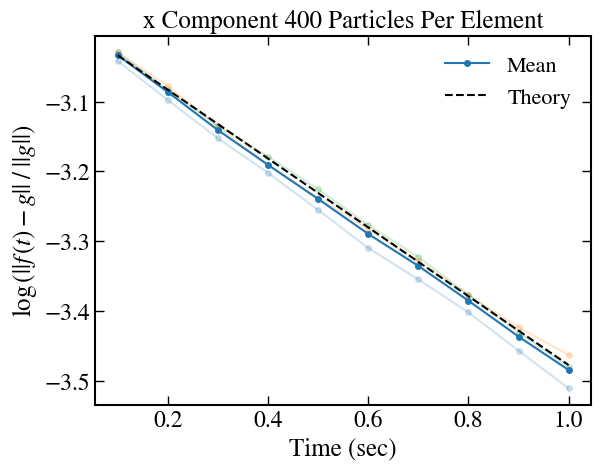

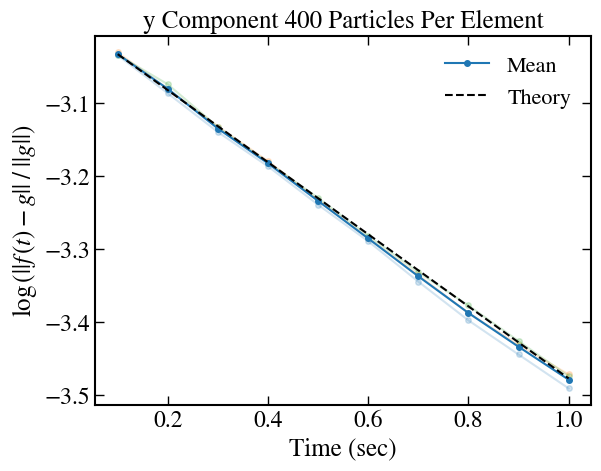

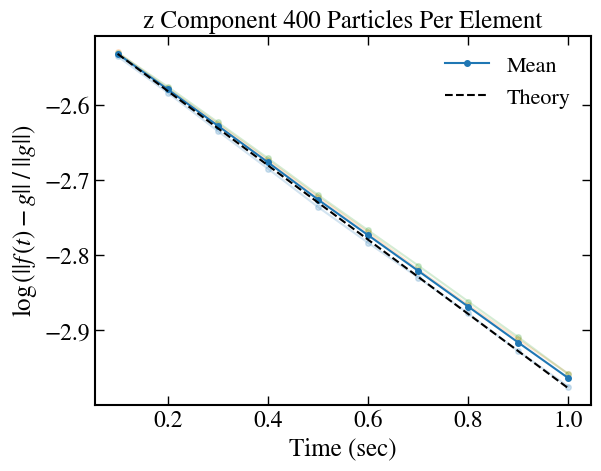

In [1223]:
runs = 3
start_idx = 0
stop_idx = 10
# ppe = (int)(1e3)
ppes = [400]
# ppes = [1000]
# ppes = [400, 1000]

components = ["x", "y", "z"]


print(f"Actual Relaxation Rate: {nu:0.4f}")
print()
for j, ppe in enumerate(ppes):
  fig_1, axs_1 = plt.subplots(1,1)
  fig_2, axs_2 = plt.subplots(1,1)
  fig_3, axs_3 = plt.subplots(1,1)
  axes = [axs_1, axs_2, axs_3]
  all_rates = []
  print(f"Particles Per Element : {ppe:d}")
  file_path = f"relax_study/100x100/{ppe:d}/run"
  # file_path = f"relax_study_random_round/100x100/{ppe:d}/run"
  mean_errors = [[], [], []]
  mean_rate = [[],[],[]]
  used_runs = 0
  for i in range(runs):
    time, errors, fitting_time, fits, rates = getGrowthRate(f"{file_path:s}{i:d}", dt=1e-2, fitting_start_index=start_idx, fitting_stop_index=stop_idx)

    for j, c in enumerate(components):
      if i == 0:
        mean_errors[j] = np.zeros_like(time)
      all_rates.append(rates[j])
      axes[j].plot(time, np.log(errors[j]), '-o', markersize=4, alpha=0.2)
      mean_errors[j] += errors[j]
      mean_rate[j].append(rates[j])

  for i, c in enumerate(components):
    mean_rate[i] = np.array(mean_rate[i])
    print(f"Relaxation Rate       : {mean_rate[i].mean():0.4f} +- {mean_rate[i].std():0.4f}")
    print(f"Relaxation Error      : {100 * abs(mean_rate[i].mean() - nu) / nu:0.4f}%")
    axes[i].plot(time, np.log(mean_errors[i] / runs), '-o', color='tab:blue', markersize=4, label="Mean")
    axes[i].plot(time, -nu * (time - time[0]) + np.log(mean_errors[i][0] / runs), 'k--', label='Theory')
    axes[i].set_title(f"{c:s} Component {ppe:d} Particles Per Element")
    axes[i].set_xlabel("Time (sec)")
    axes[i].set_ylabel("$\\log\\left(||f\\,(t) - g|| \\; / \\; ||g|| \\right)$")
    axes[i].legend()

  all_rates = np.array(all_rates)
  print(f"Mean Rate             : {all_rates.mean():0.4f} +- {all_rates.std():0.4f}")
  print(f"Mean Error            : {abs(all_rates.mean() - nu) / nu:0.4f}%")
  print()

Analytic Rate 0.4939
x Component
Computed Rate: 0.5600
Error in rate 13.3865%
y Component
Computed Rate: 0.5284
Error in rate 6.9925%
z Component
Computed Rate: 0.4982
Error in rate 0.8804%


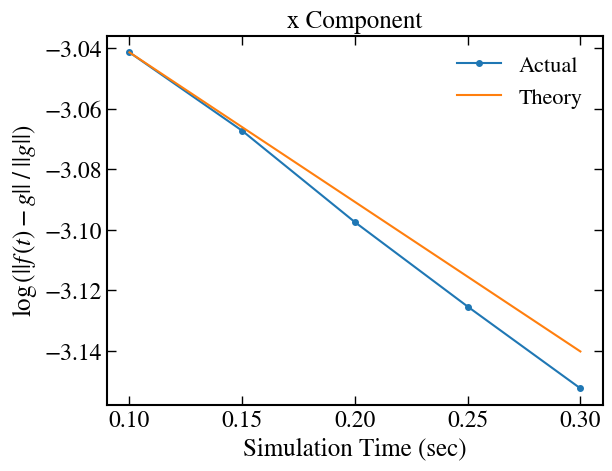

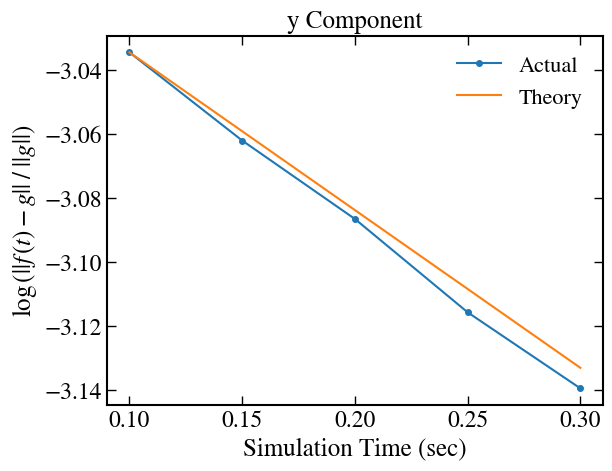

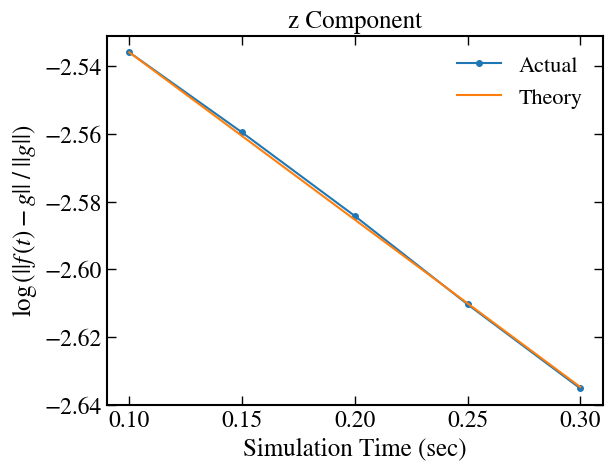

In [1221]:
runs = 1
start_idx = 0
stop_idx = 7
step_size = 5
file_path = "./"
file_path = f"relax_study/100x100/400/run0"
time, errors, fitting_time, fits, rates = getGrowthRate(file_path, dt=1e-2, fitting_start_index=start_idx, fitting_stop_index=stop_idx, end_time_step=(int)(stop_idx * step_size), step_size=step_size)

components = ["x", "y", "z"]

print(f"Analytic Rate {nu:0.4f}")
for i, c in enumerate(components):
  print(f"{c:s} Component")
  print(f"Computed Rate: {rates[i]:0.4f}")
  print(f"Error in rate {100 * abs(rates[i] - nu)/nu:0.4f}%")

  plt.figure()
  plt.plot(time, np.log(errors[i]), '-o', markersize=4, label="Actual")
  plt.plot(fitting_time, -nu * (fitting_time - fitting_time[0]) + np.log(errors[i][0]), label="Theory")
  plt.ylabel("$\\log\\left(||f\\,(t) - g|| \\; / \\; ||g|| \\right)$")
  plt.xlabel("Simulation Time (sec)")
  plt.title(f"{c:s} Component")
  plt.legend()